# Basalt CO2 Sensor Workbench

Default basalt sensor from `variables_schema.xlsx`:

- slope: `LEO East`
- x: `1`
- y: `10`
- depth: `5 cm below surface`
- table: `leo_east.datavalues`
- sensorid: `408`
- variableid: `9`


In [3]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

from basalt_co2_series import BasaltCO2Series
from diagnostics import center_series, normality_report, plot_histogram, plot_qq

sensor = BasaltCO2Series(
    table_name="leo_east.datavalues",
    sensor_id=408,
    variable_id=9,
    slope="LEO East",
    x_coord_m=1,
    y_coord_m=10,
    depth_cm=5,
)

sensor


BasaltCO2Series(table_name='leo_east.datavalues', sensor_id=408, variable_id=9, slope='LEO East', x_coord_m=1, y_coord_m=10, depth_cm=5, units='ppm')

In [2]:
coverage = sensor.describe_time_coverage()
series = sensor.fetch_series()

display(coverage)
display(series.head())
display(series.tail())
print(f"Rows fetched: {len(series):,}")


{'first_timestamp': Timestamp('2012-06-28 16:30:00'),
 'last_timestamp': Timestamp('2026-03-31 14:00:03'),
 'table_name': 'leo_east.datavalues',
 'sensor_id': 408,
 'variable_id': 9,
 'slope': 'LEO East',
 'x_coord_m': 1,
 'y_coord_m': 10,
 'depth_cm': 5,
 'units': 'ppm'}

localdatetime
2012-06-28 16:30:00   -9999.000000
2012-06-28 16:35:00     356.868009
2012-06-28 16:40:00     358.685472
2012-06-28 16:45:00     349.992717
2012-06-28 16:50:00     359.657215
Name: datavalue, dtype: float64

localdatetime
2026-03-31 13:00:01    4979.599619
2026-03-31 13:15:00    4981.000042
2026-03-31 13:30:01    4973.548953
2026-03-31 13:45:02    4976.590681
2026-03-31 14:00:03    4986.503696
Name: datavalue, dtype: float64

Rows fetched: 905,926


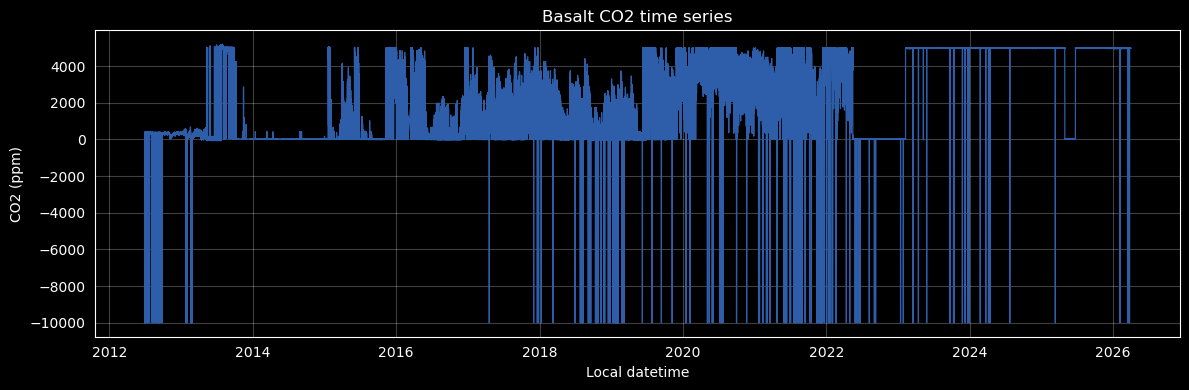

In [5]:
figure, axis = sensor.plot(series=series, title="Basalt CO2 time series")
plt.show()


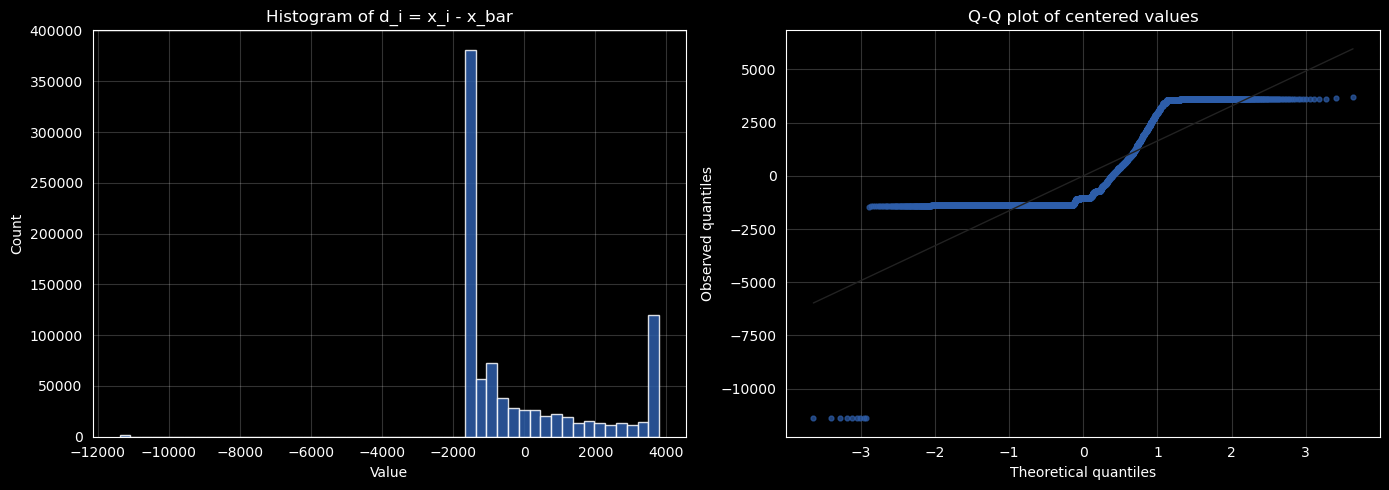

{'sample_size': 905926,
 'excluded_non_finite': 0,
 'mean': 1.891582245451042e-13,
 'standard_deviation': 1896.720592880854,
 'shapiro': {'statistic': 0.7389415402945196,
  'p_value': 1.0380619661075705e-185,
  'sample_size': 905926,
  'alpha': 0.05,
  'reject_normality': True,
  'notes': ['scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 905926.']},
 'notes': ['scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 905926.']}

In [6]:
centered = center_series(series)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_histogram(centered, ax=axes[0], title="Histogram of d_i = x_i - x_bar")
plot_qq(centered, ax=axes[1], title="Q-Q plot of centered values", max_points=5000)
plt.show()

report = normality_report(centered)
display(report.to_dict())
